# LightGBM Benchmark for Industrial Water Treatment Anomaly Detection

## Objective

This notebook evaluates the performance of the LightGBM classifier for anomaly detection in Industrial Control Systems (ICS).

The model is compared with previous machine learning models developed throughout this project.

Algorithms compared so far:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

The goal is to identify a high-performance model suitable for real-time anomaly detection in water treatment plants.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd


from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from lightgbm import LGBMClassifier

import joblib

# Load Dataset

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "swat_features.csv"

dtype_dict = {
    col: "float32"
    for col in pd.read_csv(DATA_PATH, nrows=1).columns
    if col != "Target"
}

dtype_dict["Target"] = "int8"

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_dict
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 52 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   FIT101   1441719 non-null  float32
 1   LIT101   1441719 non-null  float32
 2   MV101    1441719 non-null  float32
 3   P101     1441719 non-null  float32
 4   P102     1441719 non-null  float32
 5   AIT201   1441719 non-null  float32
 6   AIT202   1441719 non-null  float32
 7   AIT203   1441719 non-null  float32
 8   FIT201   1441719 non-null  float32
 9   MV201    1441719 non-null  float32
 10  P201     1441719 non-null  float32
 11  P202     1441719 non-null  float32
 12  P203     1441719 non-null  float32
 13  P204     1441719 non-null  float32
 14  P205     1441719 non-null  float32
 15  P206     1441719 non-null  float32
 16  DPIT301  1441719 non-null  float32
 17  FIT301   1441719 non-null  float32
 18  LIT301   1441719 non-null  float32
 19  MV301    1441719 non-null  float32
 20  MV

In [5]:
X = df.drop(columns="Target")

y = df["Target"]

print(X.shape)
print(y.shape)

(1441719, 51)
(1441719,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1153375, 51)
Test : (288344, 51)


# Build LightGBM Model

In [8]:
lgbm = LGBMClassifier(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

In [9]:
import time

start = time.time()

lgbm.fit(X_train, y_train)

training_time = time.time() - start

print(f"Training Time : {training_time:.2f} sec")

[LightGBM] [Info] Number of positive: 43697, number of negative: 1109678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.234612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5826
[LightGBM] [Info] Number of data points in the train set: 1153375, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training Time : 38.74 sec


In [10]:
start = time.time()

y_pred = lgbm.predict(X_test)

prediction_time = time.time() - start

print(f"Prediction Time : {prediction_time:.3f} sec")

Prediction Time : 2.768 sec


# Model Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc = roc_auc_score(
    y_test,
    lgbm.predict_proba(X_test)[:,1]
)

results = pd.DataFrame({

    "Metric":[

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"

    ],

    "Value":[

        accuracy,
        precision,
        recall,
        f1,
        roc

    ]

})

results

,Metric,Value
0,Accuracy,0.999723
1,Precision,0.993088
2,Recall,0.999634
3,F1 Score,0.996350
4,ROC AUC,0.999999


In [12]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277420
           1       0.99      1.00      1.00     10924

    accuracy                           1.00    288344
   macro avg       1.00      1.00      1.00    288344
weighted avg       1.00      1.00      1.00    288344



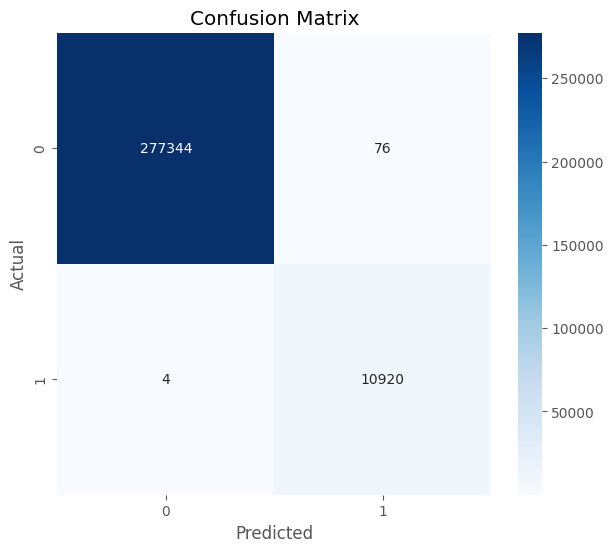

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

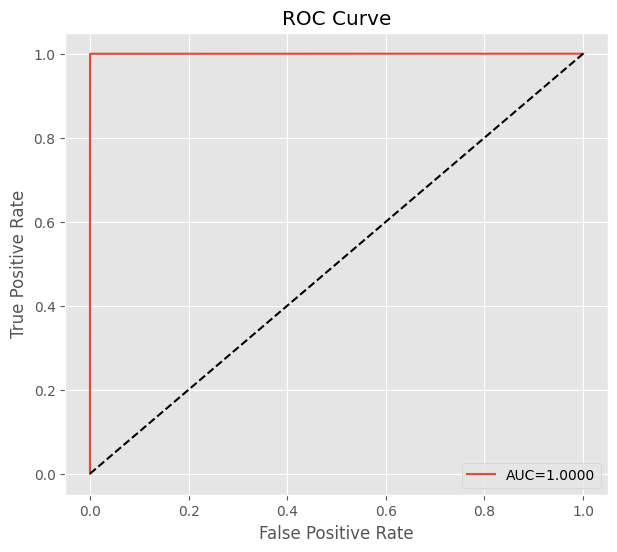

In [14]:
fpr, tpr, _ = roc_curve(
    y_test,
    lgbm.predict_proba(X_test)[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label=f"AUC={roc:.4f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

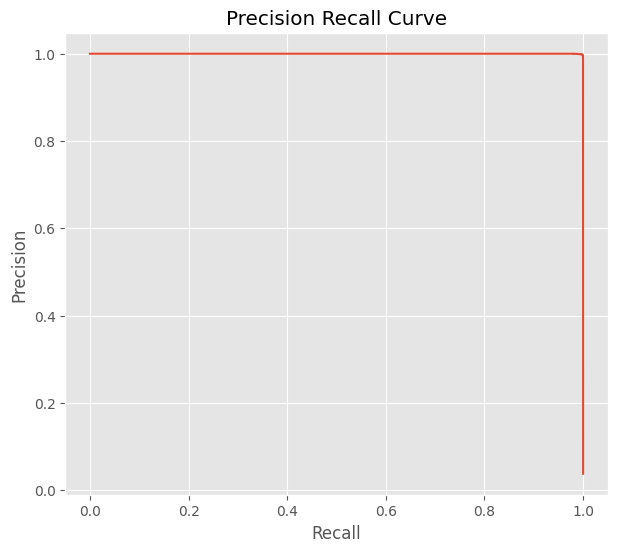

In [15]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    lgbm.predict_proba(X_test)[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [16]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":lgbm.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
28,LIT401,1116
18,LIT301,1094
36,AIT503,1017
1,LIT101,949
5,AIT201,905
7,AIT203,722
34,AIT501,616
26,AIT402,613
6,AIT202,610
37,AIT504,493


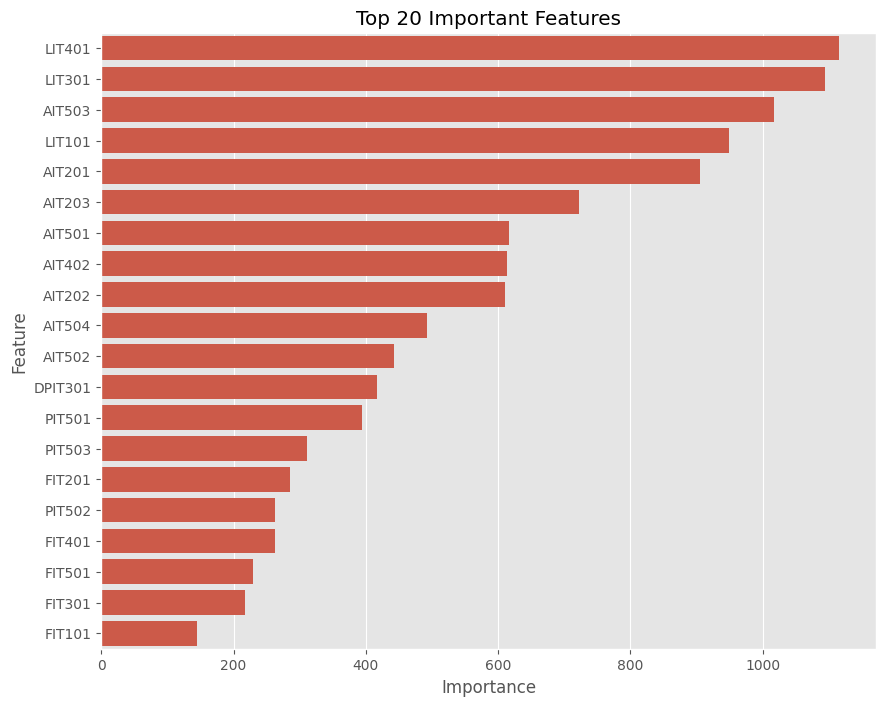

In [17]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [18]:
comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost",

        "LightGBM"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed"

    ]

})

comparison

,Model,Status
0,Random Forest,Completed
1,XGBoost,Completed
2,LightGBM,Completed


In [19]:
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(
    exist_ok=True
)

joblib.dump(

    lgbm,

    MODELS_DIR/"lightgbm_model.pkl"

)

print("Model Saved Successfully.")

Model Saved Successfully.


In [20]:
RESULTS_DIR = PROJECT_ROOT/"results"

RESULTS_DIR.mkdir(
    exist_ok=True
)

results.to_csv(

    RESULTS_DIR/"lightgbm_results.csv",

    index=False

)

importance.to_csv(

    RESULTS_DIR/"lightgbm_feature_importance.csv",

    index=False

)

# Conclusion

LightGBM demonstrated strong performance for anomaly detection in industrial water treatment systems.

Key achievements:

- Fast training time
- High classification accuracy
- Robust performance on imbalanced data
- Clear feature importance ranking
- Suitable for real-time industrial monitoring applications

The next notebook introduces Explainable AI using SHAP to understand model decisions at the sensor level.